In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

In [24]:
df_design = pd.read_csv('data/Design.csv')
df_spectro = pd.read_csv('data/Spectrophotometer.csv')
df_turbidostat = pd.read_csv('data/Turbidostat.csv')

In [25]:
print(df_design.head())

   channel    purpose  phosphate_mM
0        1  treatment        0.0115
1        3  treatment        0.0115
2        4  treatment        0.0115
3        5    control        0.2300
4        7    control        0.2300


In [7]:
print(df_spectro)

   od_value_730  od_value_685  od_value_634  od_value_720  channel
0         0.207         0.295         0.314         0.219        7
1         0.155         0.197         0.231         0.161        4
2         0.180         0.221         0.252         0.186        1
3         0.259         0.351         0.370         0.271        8
4         0.183         0.219         0.252         0.189        3
5         0.294         0.393         0.415         0.309        5


In [9]:
print(df_turbidostat.head)

<bound method NDFrame.head of       channel  decision    time_h      OD
0           1       145  297.2658  0.3343
1           1       145  297.3492  0.3338
2           1       145  297.4325  0.3318
3           1       145  297.5158  0.3338
4           1       145  297.5992  0.3318
...       ...       ...       ...     ...
1565        8       233  321.6831  0.3462
1566        8       233  321.7678  0.3475
1567        8       233  321.8497  0.3484
1568        8       233  321.9331  0.3479
1569        8       233  322.0175  0.3501

[1570 rows x 4 columns]>


## combine spectro and design dataframes

In [ ]:

df_combined = pd.merge(df_spectro, df_design, on='channel')
print(df_combined.head())

   od_value_730  od_value_685  od_value_634  od_value_720  channel    purpose  \
0         0.207         0.295         0.314         0.219        7    control   
1         0.155         0.197         0.231         0.161        4  treatment   
2         0.180         0.221         0.252         0.186        1  treatment   
3         0.259         0.351         0.370         0.271        8    control   
4         0.183         0.219         0.252         0.189        3  treatment   

   phosphate_mM  
0        0.2300  
1        0.0115  
2        0.0115  
3        0.2300  
4        0.0115  


Confidence Interval: (array([0.22953712, 0.21002834]), array([0.50409815, 1.59058364]))


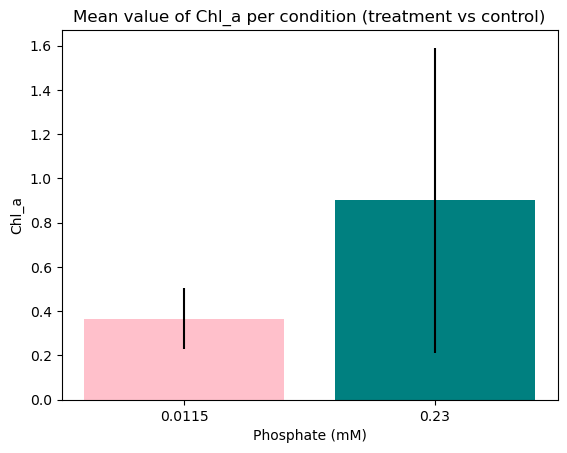

In [40]:
df_combined = pd.merge(df_spectro, df_design, on='channel')

# Calculate chlorophyll a (mg Chl a L^-1)
df_combined['chl_a'] = 10.186 * (df_combined['od_value_685'] * df_combined['od_value_730']) - 0.008

grouped = df_combined.groupby('phosphate_mM')['chl_a']
chl_a_mean = grouped.mean()
chl_a_std = grouped.std()
df_length = grouped.count()

chl_a_standard_error = chl_a_std / np.sqrt(df_length)

confidence_interval = stats.t.interval(0.95, df=df_length - 1, loc=chl_a_mean, scale=chl_a_standard_error)
print("Confidence Interval:", confidence_interval)

ci_error = chl_a_mean - confidence_interval[0]


plt.bar(chl_a_mean.index.astype(str), chl_a_mean.values, yerr=ci_error, color=['pink', 'teal'], label=['treatment', 'control'])

plt.xlabel('Phosphate (mM)')
plt.ylabel('Chl_a')
plt.title('Mean value of Chl_a per condition (treatment vs control)')
plt.show()

Confidence Interval: (array([0.27369988, 0.31186104]), array([0.57121463, 0.59283514]))


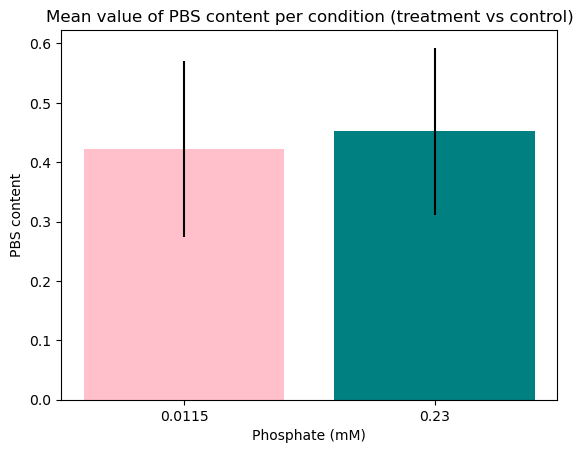

In [42]:
df_combined['PBS content'] = (df_combined['od_value_634'] - df_combined['od_value_730']) / df_combined['od_value_730']


grouped = df_combined.groupby('phosphate_mM')['PBS content']
chl_a_mean = grouped.mean()
chl_a_std = grouped.std()
df_length = grouped.count()

chl_a_standard_error = chl_a_std / np.sqrt(df_length)

confidence_interval = stats.t.interval(0.95, df=df_length - 1, loc=chl_a_mean, scale=chl_a_standard_error)
print("Confidence Interval:", confidence_interval)

ci_error = chl_a_mean - confidence_interval[0]


plt.bar(chl_a_mean.index.astype(str), chl_a_mean.values, yerr=ci_error, color=['pink', 'teal'], label=['treatment', 'control'])

plt.xlabel('Phosphate (mM)')
plt.ylabel('PBS content')
plt.title('Mean value of PBS content per condition (treatment vs control)')
plt.show()


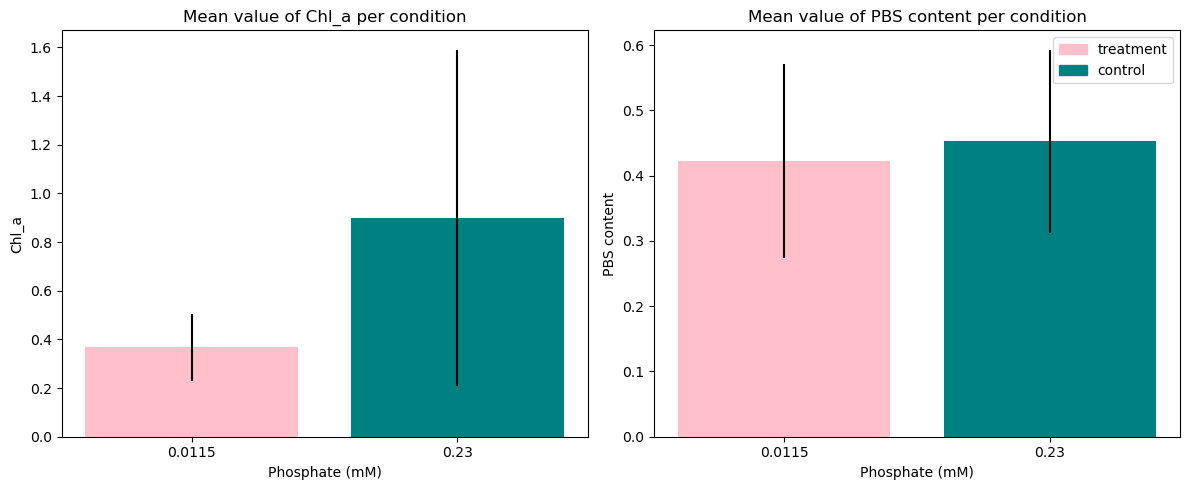

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# chl a content
grouped = df_combined.groupby('phosphate_mM')['chl_a']
chl_a_mean = grouped.mean()
chl_a_std = grouped.std()
df_length = grouped.count()
chl_a_standard_error = chl_a_std / np.sqrt(df_length)
confidence_interval = stats.t.interval(0.95, df=df_length - 1, loc=chl_a_mean, scale=chl_a_standard_error)
ci_error = chl_a_mean - confidence_interval[0]

ax1.bar(chl_a_mean.index.astype(str), chl_a_mean.values, yerr=ci_error, color=['pink', 'teal'], label=['treatment', 'control'])
ax1.set_xlabel('Phosphate (mM)')
ax1.set_ylabel('Chl_a')
ax1.set_title('Mean value of Chl_a per condition')

# pbs content
grouped = df_combined.groupby('phosphate_mM')['PBS content']
pbs_mean = grouped.mean()
pbs_std = grouped.std()
df_length = grouped.count()
pbs_standard_error = pbs_std / np.sqrt(df_length)
confidence_interval = stats.t.interval(0.95, df=df_length - 1, loc=pbs_mean, scale=pbs_standard_error)
ci_error = pbs_mean - confidence_interval[0]

ax2.bar(pbs_mean.index.astype(str), pbs_mean.values, yerr=ci_error, color=['pink', 'teal'], label=['treatment', 'control'])
ax2.set_xlabel('Phosphate (mM)')
ax2.set_ylabel('PBS content')
ax2.set_title('Mean Value of PBS content per condition')

# legend
colors = {'treatment':'pink', 'control':'teal'}         
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]



plt.tight_layout()
# plt.title('Mean values of Chl_a and PBS content per condition')
plt.legend(handles, labels)
plt.show()

